In [1]:
%%writefile kaggle.json
{
  "username": "ezatom",
  "key": ""
}


Writing kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!pip install kaggle
!kaggle datasets list | head


ref                                                                title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                                           Heart Disease                                            3491  2025-12-11 15:29:14.327000           2114        317  1.0              
mabubakrsiddiq/retail-store-product-sales-simulation-dataset       🏪 Retail Store Product Sales Simulation Dataset       1383545  2026-01-16 13:12:07.310000              0         26  1.0              
saidaminsaidaxmadov/chocolate-sales                                Chocolate Sales                                        468320  2026-01-04 14:23:35.490000              0         58  1.0     

## download dataset in cloab

In [4]:
!kaggle datasets download -d shubhamgoel27/dermnet


Dataset URL: https://www.kaggle.com/datasets/shubhamgoel27/dermnet
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 1.71G/1.72G [00:12<00:00, 240MB/s]
100% 1.72G/1.72G [00:12<00:00, 148MB/s]


In [5]:
!unzip dermnet.zip -d dermnet
!ls dermnet


Streaming output truncated to the last 5000 lines.
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keloids-80.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keloids-9.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-100.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-101.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-102.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-103.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-104.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-105.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthoma-106.jpg  
  inflating: dermnet/train/Seborrheic Keratoses and other Benign Tumors/keratoacanthom

In [6]:
!ls dermnet


test  train


## Number of classes

In [6]:
import os

train_path = "dermnet/train"

classes = sorted(os.listdir(train_path))
print("Total classes:", len(classes))

for i, cls in enumerate(classes[:20]):
    print(f"{i+1}. {cls}")


Total classes: 23
1. Acne and Rosacea Photos
2. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
3. Atopic Dermatitis Photos
4. Bullous Disease Photos
5. Cellulitis Impetigo and other Bacterial Infections
6. Eczema Photos
7. Exanthems and Drug Eruptions
8. Hair Loss Photos Alopecia and other Hair Diseases
9. Herpes HPV and other STDs Photos
10. Light Diseases and Disorders of Pigmentation
11. Lupus and other Connective Tissue diseases
12. Melanoma Skin Cancer Nevi and Moles
13. Nail Fungus and other Nail Disease
14. Poison Ivy Photos and other Contact Dermatitis
15. Psoriasis pictures Lichen Planus and related diseases
16. Scabies Lyme Disease and other Infestations and Bites
17. Seborrheic Keratoses and other Benign Tumors
18. Systemic Disease
19. Tinea Ringworm Candidiasis and other Fungal Infections
20. Urticaria Hives


In [7]:
sample_class = classes[1]
sample_path = os.path.join(train_path, sample_class)

print("Class name:", sample_class)
print("Number of images:", len(os.listdir(sample_path)))
print("Sample images:", os.listdir(sample_path)[:5])


Class name: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
Number of images: 1149
Sample images: ['ctcl-5.jpg', 'basal-cell-carcinoma-nose-73.jpg', 'granulation-tissue-2.jpg', 'actinic-keratosis-face-2.jpg', 'actinic-keratosis-5FU-52.jpg']


Text(0.5, 1.0, 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions')

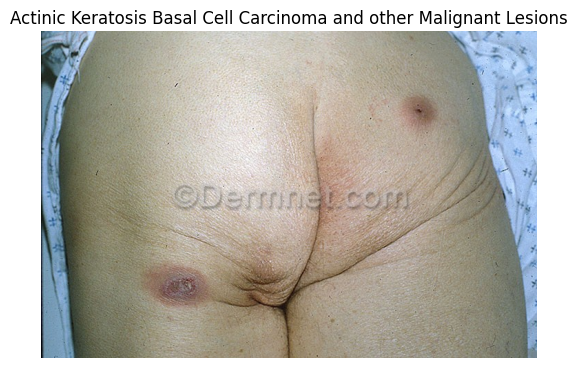

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(sample_path, os.listdir(sample_path)[0])
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(sample_class)


In [9]:
selected_classes = [
    "Acne and Rosacea Photos",
    "Atopic Dermatitis Photos",
    "Eczema Photos",
    "Cellulitis Impetigo and other Bacterial Infections",
    "Exanthems and Drug Eruptions",
    "Herpes HPV and other STDs Photos",
    "Light Diseases and Disorders of Pigmentation",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Urticaria Hives"
]


In [10]:
import shutil
import os

base_dir = "dermnet"
filtered_dir = "dermnet_filtered"

splits = ["train", "test"]

for split in splits:
    for cls in selected_classes:
        src = os.path.join(base_dir, split, cls)
        dst = os.path.join(filtered_dir, split, cls)

        if os.path.exists(src):
            os.makedirs(dst, exist_ok=True)
            for img in os.listdir(src):
                shutil.copy(os.path.join(src, img), dst)


In [11]:
import os

print("Filtered train classes:", os.listdir("dermnet_filtered/train"))
print("Number of classes:", len(os.listdir("dermnet_filtered/train")))


Filtered train classes: ['Acne and Rosacea Photos', 'Eczema Photos', 'Psoriasis pictures Lichen Planus and related diseases', 'Atopic Dermatitis Photos', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Cellulitis Impetigo and other Bacterial Infections', 'Urticaria Hives', 'Exanthems and Drug Eruptions', 'Tinea Ringworm Candidiasis and other Fungal Infections']
Number of classes: 10


In [20]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])



In [21]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_path = "dermnet_filtered/train"
test_path  = "dermnet_filtered/test"

train_data = ImageFolder(train_path, transform=train_transforms)
test_data  = ImageFolder(test_path, transform=test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
num_classes = len(class_names)

print(class_names)


['Acne and Rosacea Photos', 'Atopic Dermatitis Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Psoriasis pictures Lichen Planus and related diseases', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives']


In [14]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [22]:
import torch
import torch.nn as nn


class BetterCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes).to(device)


In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [25]:
epochs = 10

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Train Accuracy: {train_acc:.2f}%")


Epoch [1/10] Loss: 479.2312 Train Accuracy: 20.88%
Epoch [2/10] Loss: 467.2069 Train Accuracy: 21.72%
Epoch [3/10] Loss: 461.4531 Train Accuracy: 23.92%
Epoch [4/10] Loss: 457.3144 Train Accuracy: 24.59%
Epoch [5/10] Loss: 452.0866 Train Accuracy: 25.66%
Epoch [6/10] Loss: 445.5940 Train Accuracy: 27.81%
Epoch [7/10] Loss: 442.4586 Train Accuracy: 28.20%
Epoch [8/10] Loss: 437.9154 Train Accuracy: 29.22%
Epoch [9/10] Loss: 433.4114 Train Accuracy: 30.20%
Epoch [10/10] Loss: 428.8843 Train Accuracy: 31.02%


In [26]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 31.17%


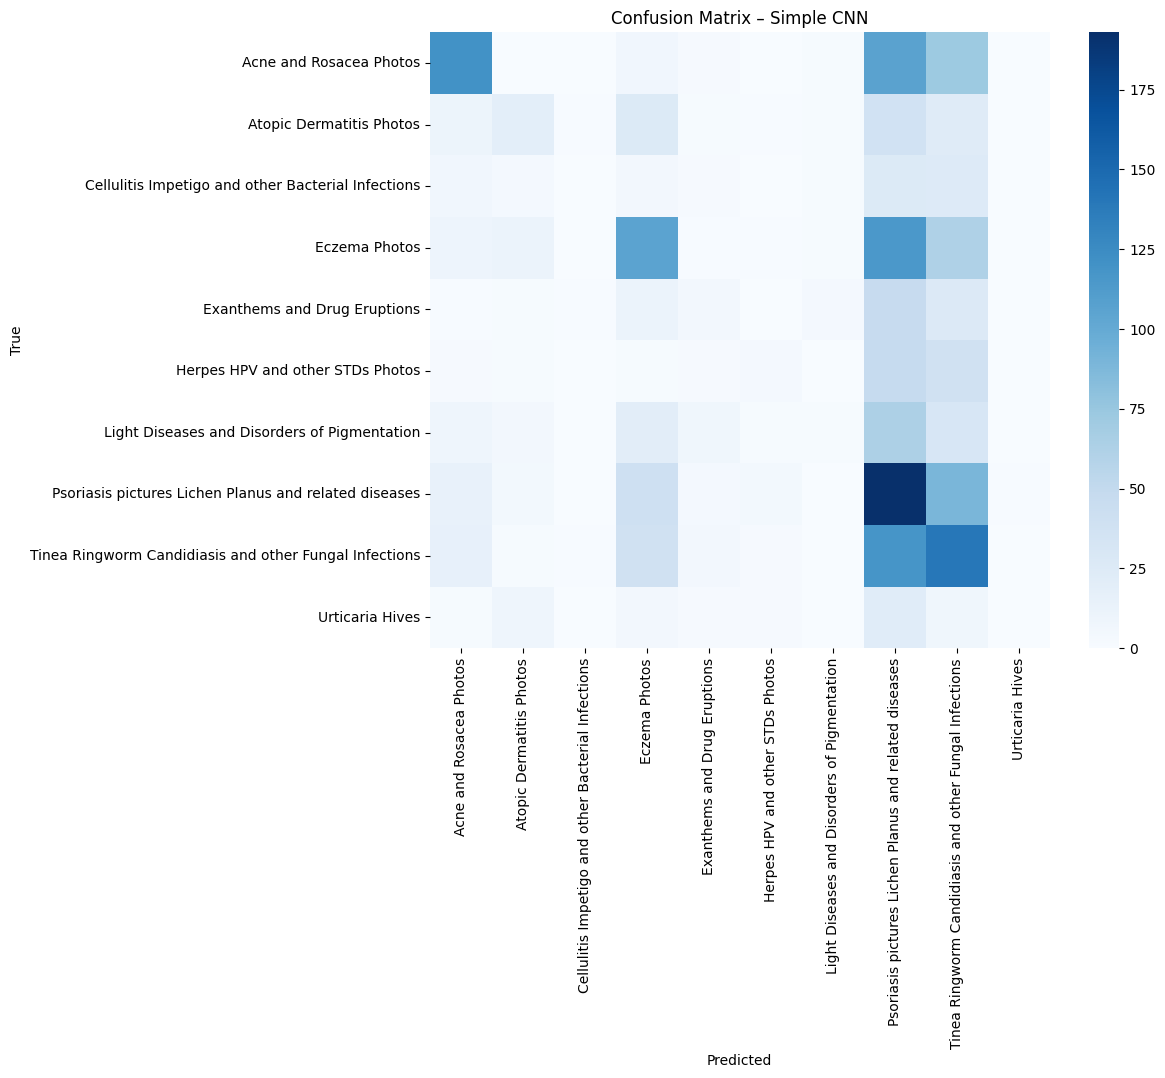

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names,
            annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Simple CNN")
plt.show()
